# US Accidents Data Cleaning - Part 1: Basic Cleaning
ใน Notebook นี้เราจะดำเนินการทำความสะอาดข้อมูลเบื้องต้น (Basic Cleaning) เพื่อเตรียมพร้อมสำหรับการทำ EDA และ Feature Engineering ในขั้นตอนถัดไป

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append('../src')

import util as ut

In [2]:
df_experiment = pd.read_csv("../data/raw/US_Accidents_March23.csv")

## 2. Initial Data Exploration

In [3]:
df_experiment.shape

(7728394, 46)

In [4]:
df_experiment.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


In [5]:
df_experiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

## 3. Missing Value Analysis

#### Show Null counts and percentages

In [6]:
missing_data = df_experiment.isnull().sum()[df_experiment.isnull().sum() > 0].sort_values(ascending=False)

print("--- Number of Null ---")
print(missing_data)

--- Number of Null ---
End_Lat                  3402762
End_Lng                  3402762
Precipitation(in)        2203586
Wind_Chill(F)            1999019
Wind_Speed(mph)           571233
Visibility(mi)            177098
Wind_Direction            175206
Humidity(%)               174144
Weather_Condition         173459
Temperature(F)            163853
Pressure(in)              140679
Weather_Timestamp         120228
Sunrise_Sunset             23246
Civil_Twilight             23246
Nautical_Twilight          23246
Astronomical_Twilight      23246
Airport_Code               22635
Street                     10869
Timezone                    7808
Zipcode                     1915
City                         253
Description                    5
dtype: int64


In [7]:
missing_percent = (df_experiment.isnull().sum() / len(df_experiment)) * 100
missing_df = missing_percent[missing_percent > 0].sort_values(ascending=False)

print("--- Percent of Null ---")
print(missing_df)

--- Percent of Null ---
End_Lat                  44.029355
End_Lng                  44.029355
Precipitation(in)        28.512858
Wind_Chill(F)            25.865904
Wind_Speed(mph)           7.391355
Visibility(mi)            2.291524
Wind_Direction            2.267043
Humidity(%)               2.253301
Weather_Condition         2.244438
Temperature(F)            2.120143
Pressure(in)              1.820288
Weather_Timestamp         1.555666
Sunrise_Sunset            0.300787
Civil_Twilight            0.300787
Nautical_Twilight         0.300787
Astronomical_Twilight     0.300787
Airport_Code              0.292881
Street                    0.140637
Timezone                  0.101030
Zipcode                   0.024779
City                      0.003274
Description               0.000065
dtype: float64


## 4. Data Cleaning: Duplicates & Low-Missing Rows

#### Drop duplicate rows

In [8]:
df_experiment = df_experiment.drop_duplicates()

#### Drop the lines that contain null values ​​in those columns.

In [9]:
# Threshole 2 %
threshold_percent = 2.0
cols_to_dropna = missing_percent[(missing_percent > 0) & (missing_percent <= threshold_percent)].index.tolist()

print("--- Columns that contain less than 2% null ---")
print(cols_to_dropna)

--- Columns that contain less than 2% null ---
['Description', 'Street', 'City', 'Zipcode', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Pressure(in)', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


In [10]:
rows_before = df_experiment.shape[0]
df_experiment = df_experiment.dropna(subset=cols_to_dropna)
    
rows_after = df_experiment.shape[0]
rows_dropped = rows_before - rows_after
    
print(f"Number of rows delete: {rows_dropped:,} rows ({(rows_dropped/rows_before)*100:.2f}%)")
print(f"Number of rows remaining: {rows_after:,} rows")

Number of rows delete: 171,516 rows (2.22%)
Number of rows remaining: 7,556,878 rows


## 5. Feature Engineering: Datetime & Target Duration

#### Change time format

In [11]:
df_experiment["Start_Time"] = pd.to_datetime(df_experiment["Start_Time"], errors="coerce")
df_experiment["End_Time"] = pd.to_datetime(df_experiment["End_Time"], errors="coerce")

# Target Column
df_experiment["Duration(min)"] = (df_experiment["End_Time"] - df_experiment["Start_Time"]).dt.total_seconds() / 60.0

In [12]:
df_experiment.dropna(subset=["Start_Time", "End_Time", "Duration(min)"], inplace=True)

#### Check Nagative Duration 

In [13]:
print(f"Negative durations: {(df_experiment['Duration(min)'] < 0).sum()} rows")

Negative durations: 0 rows


## 6. Categorical Data Consistency & Cleaning

#### Check Unique Values for Categorical Columns

In [14]:
categorical_columns = df_experiment.select_dtypes(include=['object', 'bool']).columns

print(f"--- Unique Values in Categorical Columns ({len(categorical_columns)} columns) ---\n")
for col in categorical_columns:
    n_unique = df_experiment[col].nunique()
    print(f"{col:25} | Unique: {n_unique:10,}")

    if n_unique <= 20:
        print(f"Values: {df_experiment[col].unique()}")
    print("-" * 50)

--- Unique Values in Categorical Columns (31 columns) ---

ID                        | Unique:  6,836,365
--------------------------------------------------
Source                    | Unique:          3
Values: ['Source2' 'Source3' 'Source1']
--------------------------------------------------
Description               | Unique:  3,474,814
--------------------------------------------------
Street                    | Unique:    314,498
--------------------------------------------------
City                      | Unique:     12,316
--------------------------------------------------
County                    | Unique:      1,818
--------------------------------------------------
State                     | Unique:         49
--------------------------------------------------
Zipcode                   | Unique:    758,268
--------------------------------------------------
Country                   | Unique:          1
Values: ['US']
--------------------------------------------------
Time

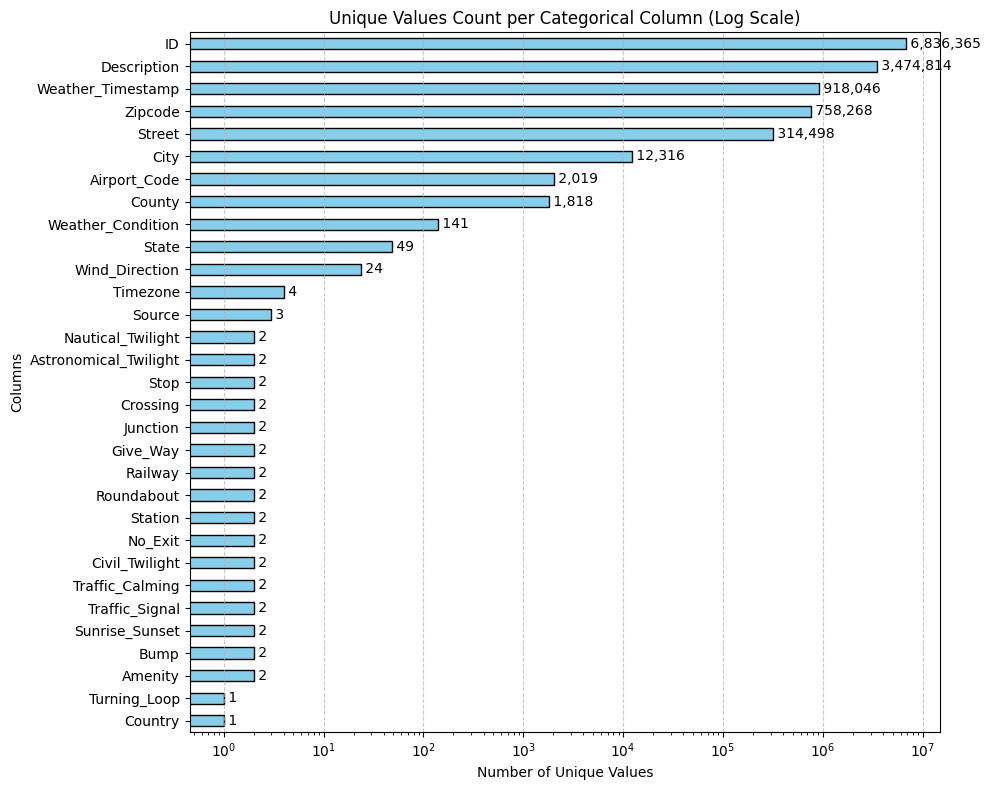

In [15]:
unique_counts = df_experiment[categorical_columns].nunique().sort_values()

plt.figure(figsize=(10, 8))
ax = unique_counts.plot(kind='barh', color='skyblue', edgecolor='black')
plt.xscale('log')
plt.title('Unique Values Count per Categorical Column (Log Scale)')
plt.xlabel('Number of Unique Values')
plt.ylabel('Columns')

# Add count labels on bars
for i, v in enumerate(unique_counts):
    ax.text(v, i, f' {v:,}', va='center')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Check Wind direction

In [16]:
df_experiment["Wind_Direction"].unique()

array(['Calm', 'SW', 'SSW', 'WSW', 'WNW', 'NW', 'West', 'NNW', 'NNE',
       'South', 'North', 'Variable', 'SE', 'SSE', 'ESE', 'East', 'NE',
       'ENE', 'E', 'W', 'S', 'VAR', nan, 'CALM', 'N'], dtype=object)

In [17]:
df_experiment['Wind_Direction'] = df_experiment['Wind_Direction'].replace({
    'North': 'N',
    'South': 'S',
    'East': 'E',
    'West': 'W',
    'Variable': 'VAR',
    'CALM': 'Calm'
})

print(f"Unique Wind Direction after fix: {df_experiment['Wind_Direction'].unique()}")

Unique Wind Direction after fix: ['Calm' 'SW' 'SSW' 'WSW' 'WNW' 'NW' 'W' 'NNW' 'NNE' 'S' 'N' 'VAR' 'SE'
 'SSE' 'ESE' 'E' 'NE' 'ENE' nan]


#### Consistency Check (County & City)

In [18]:
print("--- Shortest County Names ---")
county_names = df_experiment['County'].unique().astype(str)
shortest_counties = sorted(county_names, key=len)[:20]
print(shortest_counties)

--- Shortest County Names ---
[np.str_('Lee'), np.str_('Sac'), np.str_('Bay'), np.str_('Kay'), np.str_('Nye'), np.str_('Elk'), np.str_('Lea'), np.str_('Ida'), np.str_('Ada'), np.str_('Bee'), np.str_('Jay'), np.str_('Gem'), np.str_('Wood'), np.str_('Ross'), np.str_('Yolo'), np.str_('Lake'), np.str_('Napa'), np.str_('Yuba'), np.str_('Polk'), np.str_('Levy')]


In [19]:
print("--- Shortest City Names ---")
county_names = df_experiment['City'].unique().astype(str)
shortest_counties = sorted(county_names, key=len)[:20]
print(shortest_counties)

--- Shortest City Names ---
[np.str_('Ona'), np.str_('Iva'), np.str_('Rex'), np.str_('Ada'), np.str_('Rye'), np.str_('Lee'), np.str_('Ray'), np.str_('Gap'), np.str_('Yoe'), np.str_('Van'), np.str_('Roy'), np.str_('Elk'), np.str_('Bow'), np.str_('Leo'), np.str_('Ely'), np.str_('Ajo'), np.str_('Ina'), np.str_('Opp'), np.str_('Dix'), np.str_('Jay')]


#### Drop Column with has 1 unique value

In [20]:
df_experiment.drop(["Country", "Turning_Loop"], axis=1, inplace=True)

## 7. Outlier Analysis & Treatment

#### Check Outlier

In [21]:
ut.skewed(df_experiment)

[SKEWED]     Severity                       skew = +1.642  →  highly skewed right (positive)
[NORMAL]     Start_Lat                      skew = -0.056  →  approximately symmetric
[NORMAL]     Start_Lng                      skew = -0.481  →  approximately symmetric
[NORMAL]     End_Lat                        skew = -0.152  →  approximately symmetric
[NORMAL]     End_Lng                        skew = -0.333  →  approximately symmetric
[SKEWED]     Distance(mi)                   skew = +22.440  →  highly skewed right (positive)
[MODERATE]   Temperature(F)                 skew = -0.506  →  moderately skewed left (negative)
[MODERATE]   Wind_Chill(F)                  skew = -0.649  →  moderately skewed left (negative)
[NORMAL]     Humidity(%)                    skew = -0.405  →  approximately symmetric
[SKEWED]     Pressure(in)                   skew = -3.706  →  highly skewed left (negative)
[SKEWED]     Visibility(mi)                 skew = +2.495  →  highly skewed right (positive)
[SKEWE

#### Enhanced Outlier Visualization
เนื่องจาก Box Plot ปกติอาจจะถูก Outlier ที่รุนแรงดึงจนดูไม่ออก เราจะใช้ Histogram (Log Scale) คู่กับ Box Plot เพื่อให้เห็นการกระจายตัวในส่วนหาง (Tails) ได้ชัดเจนขึ้น

In [22]:
import seaborn as sns

def plot_enhanced_outliers(df, column):
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(12, 6))
    
    # Boxplot
    sns.boxplot(x=df[column], ax=ax_box, color="salmon")
    ax_box.set(xlabel='')
    ax_box.set_title(f'Enhanced Outlier Analysis for {column}')
    
    # Histogram with Log Scale
    sns.histplot(df[column], ax=ax_hist, kde=True, bins=100)
    ax_hist.set_yscale('log')
    plt.ylabel('Count (Log Scale)')
    
    # Add percentile lines
    q99 = df[column].quantile(0.99)
    plt.axvline(q99, color='r', linestyle='--', label=f'99th Percentile ({q99:.2f})')
    plt.legend()
    
    plt.show()

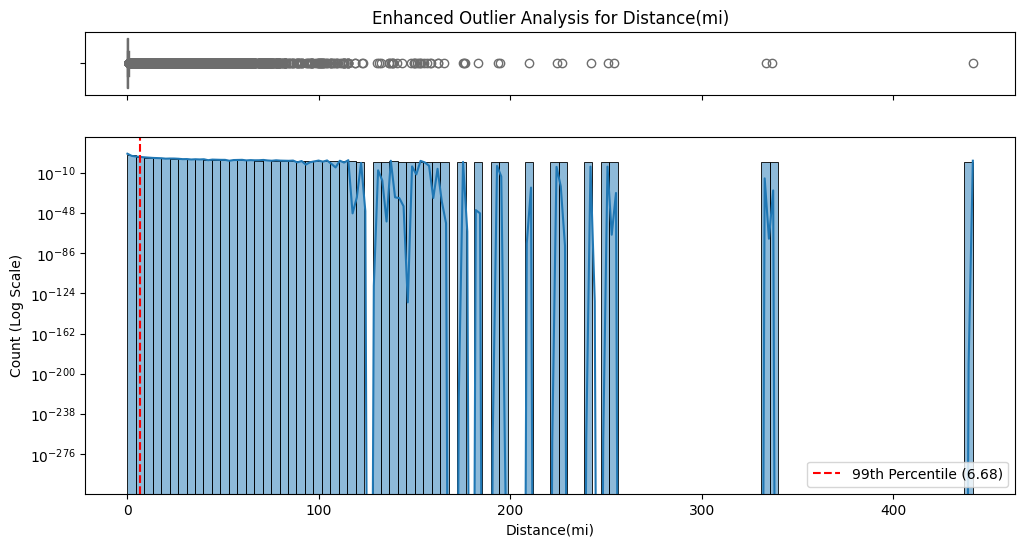

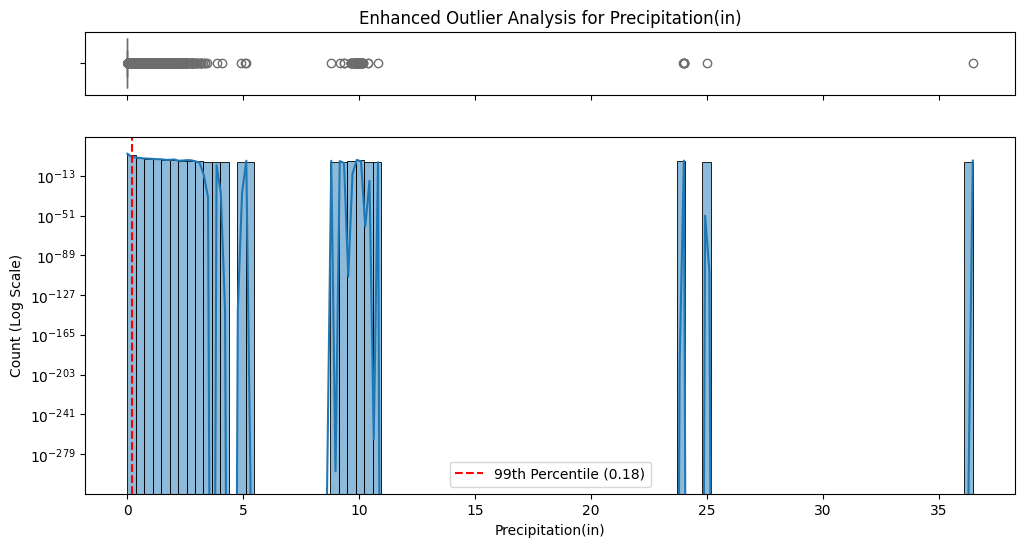

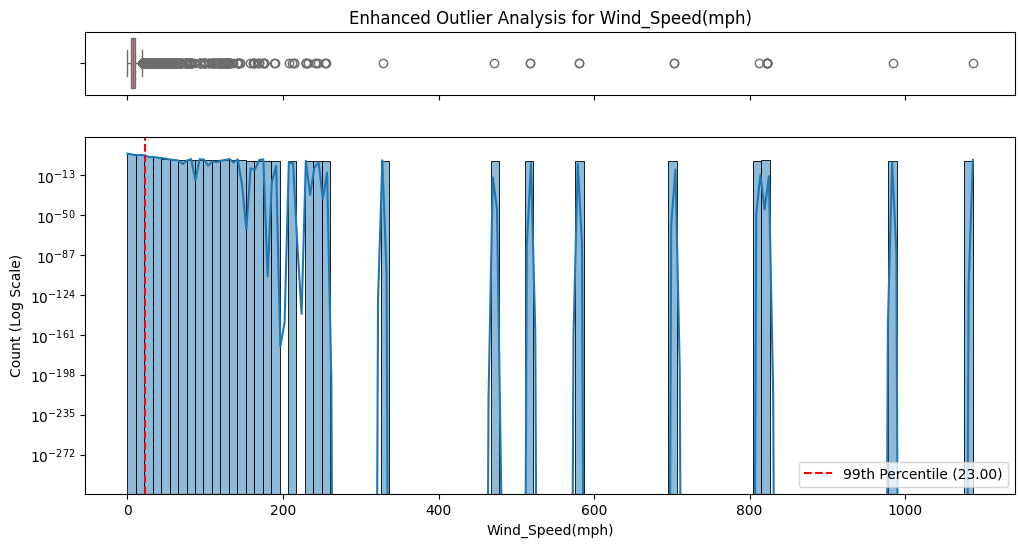

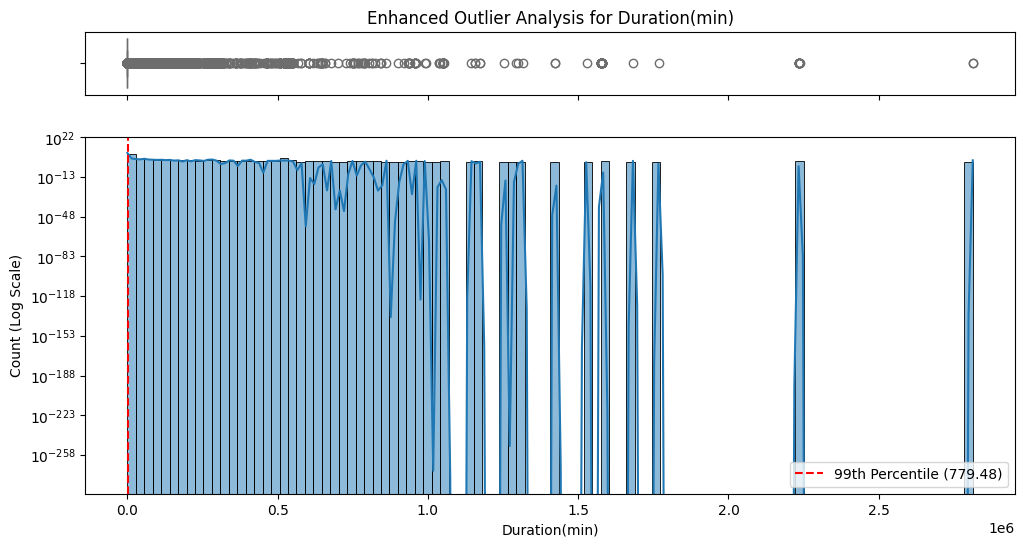

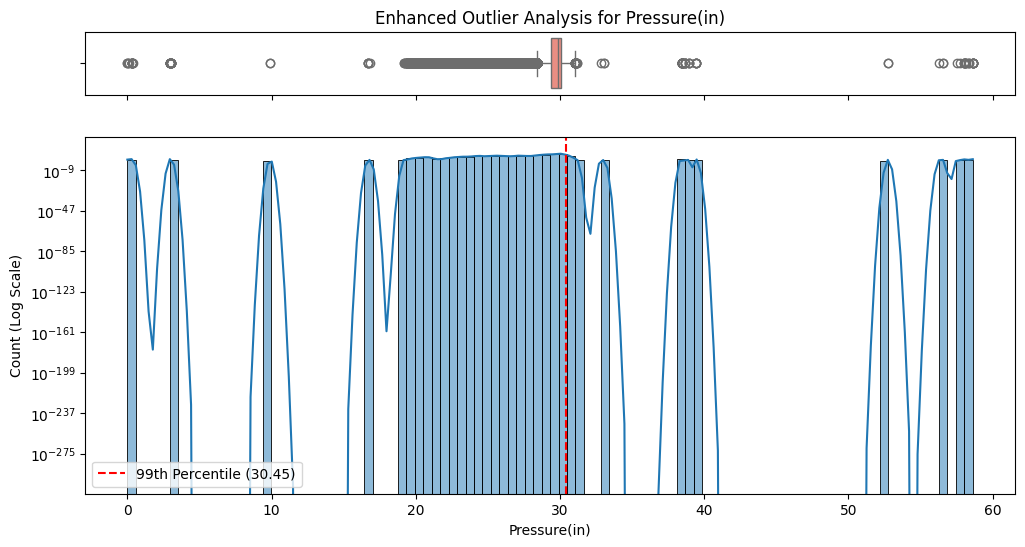

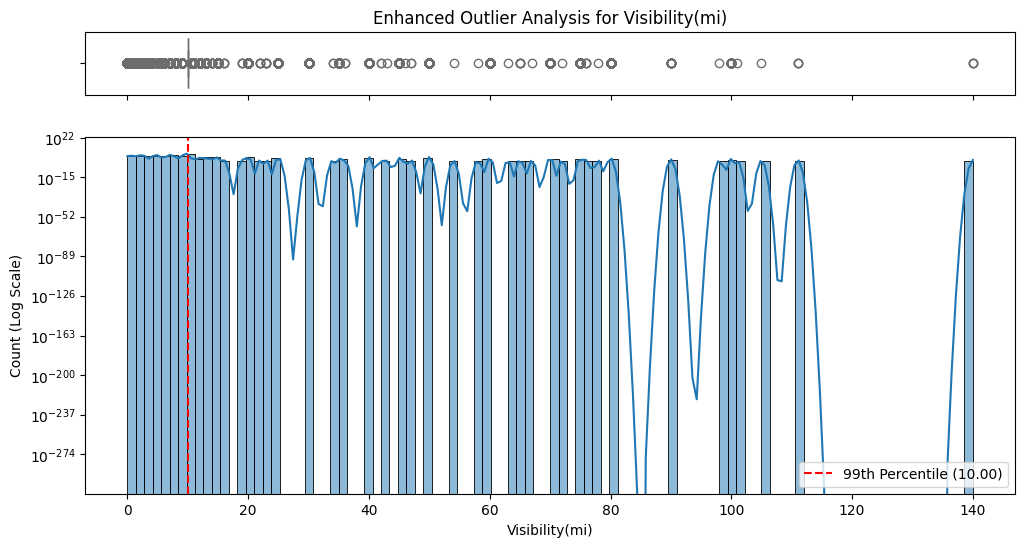

In [ ]:
# ตัวอย่างการดู Distance และ Duration
plot_enhanced_outliers(df_experiment, 'Distance(mi)')
plot_enhanced_outliers(df_experiment, 'Precipitation(in)')
plot_enhanced_outliers(df_experiment, 'Wind_Speed(mph)')
plot_enhanced_outliers(df_experiment, 'Duration(min)')
plot_enhanced_outliers(df_experiment, 'Pressure(in)')
plot_enhanced_outliers(df_experiment, 'Visibility(mi)')
plot_enhanced_outliers(df_experiment, 'Severity')

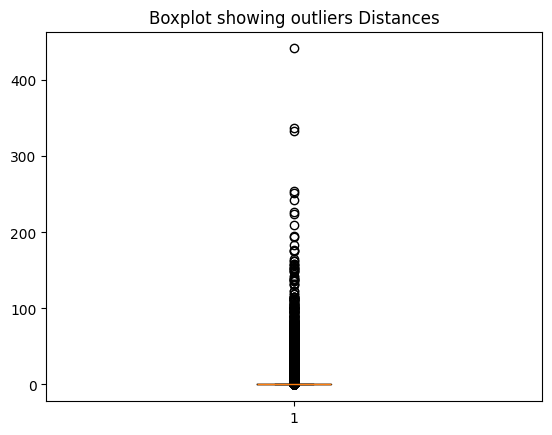

0.950     2.466
0.990     6.685
0.999    19.992
Name: Distance(mi), dtype: float64

In [24]:
# Distance
plt.boxplot(df_experiment["Distance(mi)"])
plt.title("Boxplot showing outliers Distances")
plt.show()

df_experiment["Distance(mi)"].quantile([0.95, 0.99, 0.999])

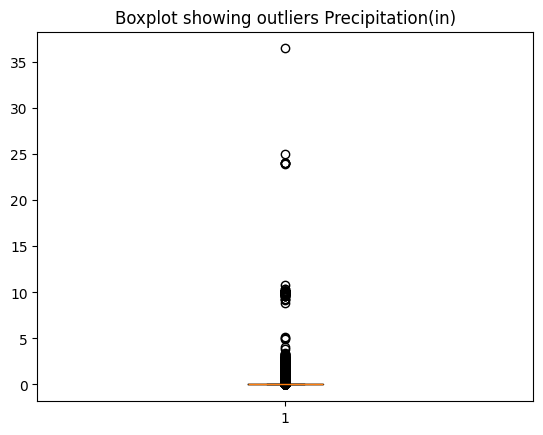

0.950    0.03
0.990    0.18
0.999    0.70
Name: Precipitation(in), dtype: float64

In [25]:
# Precipitation(in)
plt.boxplot(df_experiment["Precipitation(in)"].dropna())
plt.title("Boxplot showing outliers Precipitation(in)")
plt.show()

df_experiment["Precipitation(in)"].quantile([0.95, 0.99, 0.999])

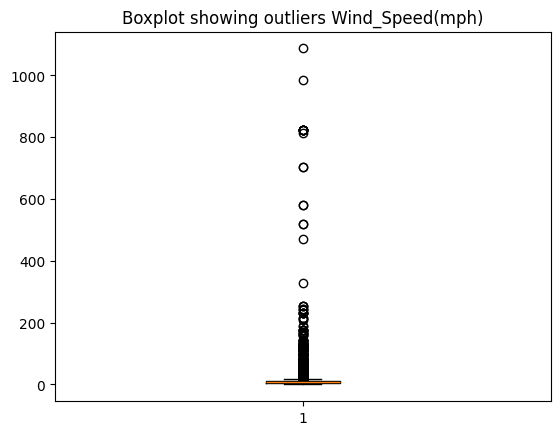

0.950    17.0
0.990    23.0
0.999    31.0
Name: Wind_Speed(mph), dtype: float64

In [26]:
# Wind Speed
plt.boxplot(df_experiment["Wind_Speed(mph)"].dropna())
plt.title("Boxplot showing outliers Wind_Speed(mph)")
plt.show()

df_experiment["Wind_Speed(mph)"].quantile([0.95, 0.99, 0.999])

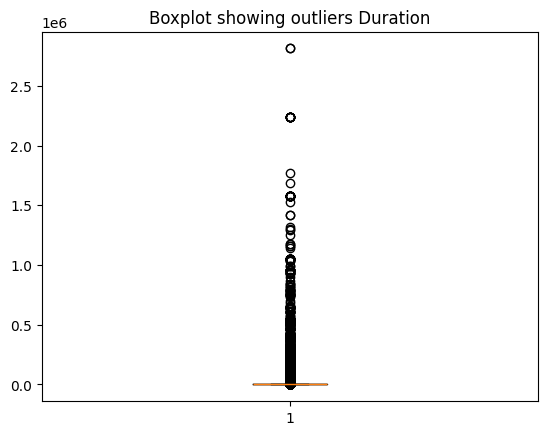

0.950     360.000000
0.990     779.483333
0.999    5718.389333
Name: Duration(min), dtype: float64

In [27]:
# Duration
plt.boxplot(df_experiment["Duration(min)"])
plt.title("Boxplot showing outliers Duration")
plt.show()

df_experiment["Duration(min)"].quantile([0.95, 0.99, 0.999])

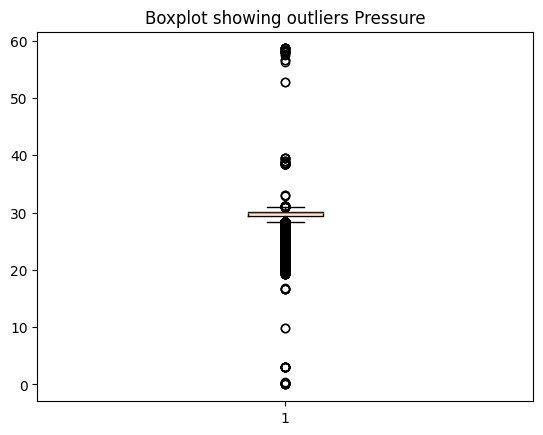

0.950    30.26
0.990    30.45
0.999    30.68
Name: Pressure(in), dtype: float64

In [28]:
# Pressure
plt.boxplot(df_experiment["Pressure(in)"].dropna())
plt.title("Boxplot showing outliers Pressure")
plt.show()

df_experiment["Pressure(in)"].quantile([0.95, 0.99, 0.999])

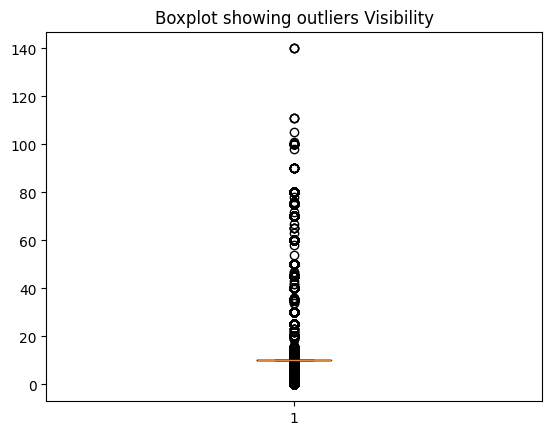

0.950    10.0
0.990    10.0
0.999    30.0
Name: Visibility(mi), dtype: float64

In [29]:
# Visibility
plt.boxplot(df_experiment["Visibility(mi)"].dropna())
plt.title("Boxplot showing outliers Visibility")
plt.show()

df_experiment["Visibility(mi)"].quantile([0.95, 0.99, 0.999])

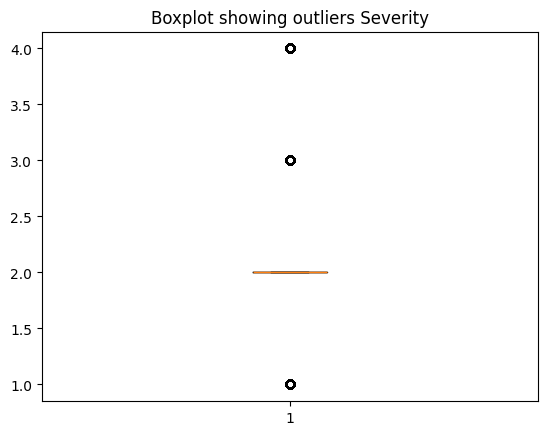

0.950    3.0
0.990    4.0
0.999    4.0
Name: Severity, dtype: float64

In [30]:
# Visibility
plt.boxplot(df_experiment["Severity"])
plt.title("Boxplot showing outliers Severity")
plt.show()

df_experiment["Severity"].quantile([0.95, 0.99, 0.999])

#### Manage excessively Outlier

## 8. Final Feature Selection & Data Export

In [31]:
outlier_columns = ["Distance(mi)", "Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)", "Duration(min)"]

df_outlier = ut.manage_outlier(df_experiment, outlier_columns=outlier_columns)

In [32]:
len(df_outlier)

6836365

In [33]:
cols_to_drop = [
    "ID", "Source",
    "End_Lat", "End_Lng",
    "Timezone", "Airport_Code", "Weather_Timestamp",
    "End_Time"
]

df_basic_clean = df_outlier.drop(columns=cols_to_drop, errors="ignore")

#### Export to CSV

In [34]:
# print(f"Number of rows: {df_basic_clean.shape[0]:,} rows")

# df_basic_clean.to_csv("../data/processed/01.1/accidents_basic_clean.csv", index=False)